# Figures 2I-J

In [1]:
# Import libraries
from tkinter.filedialog import askdirectory
from tkinter import Tk
import os
os.environ["OUTDATED_IGNORE"] = "1"
import pickle
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pingouin as pg

cur_dir = Path(os.getcwd())
src_dir = cur_dir.parent.parent
os.chdir(src_dir)
from functions.scale_bars import add_scalebar
from functions.photom_plots import make_boxplot, plot_mean_over_mice
os.chdir(cur_dir)

############################################################
DS_rate = 10 #standard sampling rate of input data
############################################################

plt.rcParams['figure.figsize'] = [9,10.5] # Make default figure size larger.
plt.rcParams['axes.xmargin'] = 0          # Make default margin on x axis zero.
plt.rcParams.update({'font.size': 16})

In [2]:
###############################
# Define which stimuli to plot:
StimsToPlot = ['chow', 'waterBowl']
my_colors = ['#ff7f0e', '#547ede']
DS = 10 #how much to downsample for plots
###############################
# Set these variables to determine how long before each event type to plot
ContactPreTime = 3 #in mins
BitePreTime = 3 #in mins
FinishPreTime = 5 #in mins
###############################

# Convert to seconds
ContactPreTime = ContactPreTime*60
FinishPreTime = FinishPreTime*60
BitePreTime = BitePreTime*60

# Open a dialog box to select the directory to be analyzed
# (so that this code block can be run independently of the merging block above)
window = Tk()
window.wm_attributes('-topmost', 1)
window.withdraw()
Dir2 = askdirectory(parent = window)
os.chdir(Dir2 + '/')

# Load data
with open('AllTrialsData.pkl', 'rb') as f:
    AllTrials = pickle.load(f)

In [3]:
# Initialize dataframe to contain mouse means (for dF/F0 AND z-score)
my_cols = pd.MultiIndex(levels = [[],[]], codes = [[],[]],
                            names = [u'Mouse',u'Stim'])
MouseMeans_Aligned = {}
MouseMeans_Aligned['dFF0'] = {}
MouseMeans_Aligned['dFF0']['Drop'] = pd.DataFrame(index = AllTrials['Drop_dFF0'].index, columns = my_cols)
MouseMeans_Aligned['ZS'] = {}
MouseMeans_Aligned['ZS']['Drop'] = pd.DataFrame(index = AllTrials['Drop_dFF0'].index, columns = my_cols)

for Mouse in list(set(AllTrials['MouseID'])): #loop through mice
    MouseTrials_dFF0 = AllTrials['Drop_dFF0'].xs(Mouse, level=0, axis=1) # take the trials from this mouse
    MouseTrials_ZS = AllTrials['Drop_ZS'].xs(Mouse, level=0, axis=1)
    # loop through unique stimulus IDs for this mouse
    for Stim in list(set(MouseTrials_dFF0.columns.get_level_values(1))):
        # return the trials for this stimulus
        ThisStimTrials_dFF0 = MouseTrials_dFF0.xs(Stim, level=1, axis=1)
        ThisStimTrials_ZS = MouseTrials_ZS.xs(Stim, level=1, axis=1)
        # calculate mean over trials for this mouse
        ThisMouseMean_dFF0 = pd.DataFrame(np.mean(ThisStimTrials_dFF0,1), 
                                                index=list(MouseTrials_dFF0.index), columns=pd.MultiIndex.from_arrays([[Mouse],[Stim]]))
        ThisMouseMean_ZS = pd.DataFrame(np.mean(ThisStimTrials_ZS,1), 
                                                index=list(MouseTrials_ZS.index), columns=pd.MultiIndex.from_arrays([[Mouse],[Stim]]))
        # add to dataframe
        MouseMeans_Aligned['dFF0']['Drop'] = pd.concat([MouseMeans_Aligned['dFF0']['Drop'],ThisMouseMean_dFF0], axis=1)
        MouseMeans_Aligned['ZS']['Drop'] = pd.concat([MouseMeans_Aligned['ZS']['Drop'],ThisMouseMean_ZS], axis=1)
        del(ThisMouseMean_dFF0,ThisMouseMean_ZS,ThisStimTrials_dFF0,ThisStimTrials_ZS)
    del(MouseTrials_dFF0,MouseTrials_ZS)

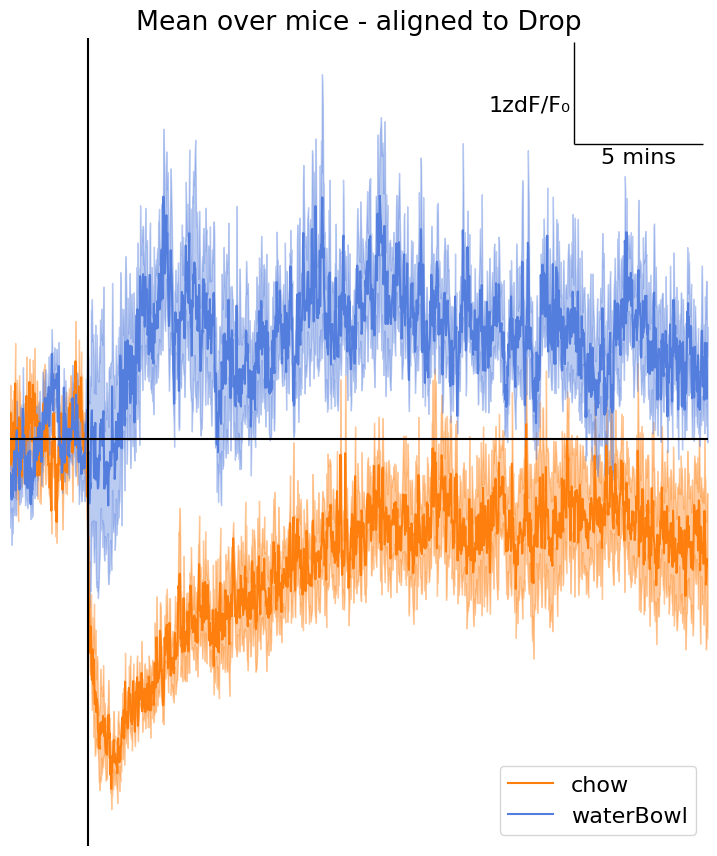

In [4]:
# Plot z-scored dF/F0 aligned to drop
fig, ax = plot_mean_over_mice(Stims = StimsToPlot, Signal = 'ZS', AlignedTo = 'Drop', MouseData=MouseMeans_Aligned, my_colors=my_colors, DS=DS)
add_scalebar(ax, matchx=False, matchy=False, sizex=300, sizey=1, hidex=True, hidey=True,
             labelx='5 mins', labely=u'1zdF/F\u2080', loc='upper right')
ax.axhline(0, color='black')
#fig.savefig('zs DropAligned '+ ', '.join(StimsToPlot) + '_MeanOverMice.png')
#fig.savefig('zs DropAligned '+ ', '.join(StimsToPlot) + '_MeanOverMice.pdf')

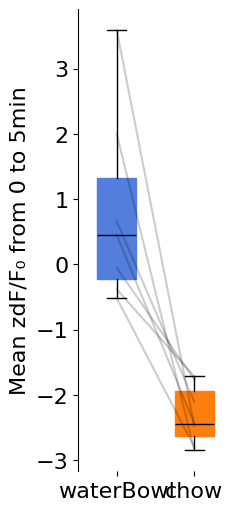

In [5]:
# Quantification
quant = MouseMeans_Aligned['ZS']['Drop'].loc[1:60*5].mean(axis=0)
quant = quant.unstack(level=1)
quant = quant[quant.columns[::-1]]

fig, ax = make_boxplot(quant, my_colors=list(reversed(my_colors)))

In [7]:
pg.ttest(x=quant['chow'], y=quant['waterBowl'], paired=True)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,-4.819146,6,two-sided,0.002943,"[-4.72, -1.54]",2.848494,17.428,0.999982
